# 06. Model Selection - Pandas

## 06.1. Importação das bibliotecas

### 06.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
from typing import Any

### 06.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

### 06.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 06.2. Visão geral dos dados

### 06.2.1. Habilitando a exibição de todas as colunas e linhas

In [4]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 06.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 06.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(581983, 19)

### 06.2.4. Exibindo o dataset

In [7]:
df.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,price,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1,2,2,Real Bed,270.0,51.0,4,t,f,strict,2018,4
1,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1,1,2,Real Bed,161.0,45.0,4,f,f,strict,2018,4
2,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1,1,2,Real Bed,222.0,68.0,2,t,f,strict,2018,4
3,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1,1,2,Real Bed,308.0,86.0,2,f,f,strict,2018,4
4,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1,1,2,Real Bed,219.0,80.0,3,t,f,strict,2018,4


### 06.2.5. Visualizando os detalhes do dataset

In [8]:
df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581983 entries, 0 to 581982
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   host_is_superhost         581983 non-null  object 
 1   host_listings_count       581983 non-null  float64
 2   latitude                  581983 non-null  float64
 3   longitude                 581983 non-null  float64
 4   property_type             581983 non-null  object 
 5   room_type                 581983 non-null  object 
 6   accommodates              581983 non-null  int64  
 7   bathrooms                 581983 non-null  int64  
 8   bedrooms                  581983 non-null  int64  
 9   beds                      581983 non-null  int64  
 10  bed_type                  581983 non-null  object 
 11  price                     581983 non-null  float64
 12  extra_people              581983 non-null  float64
 13  minimum_nights            581983 non-null  i

### 06.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,minimum_nights,ano,mes
count,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00
mean,1.71,-22.96,-43.25,3.47,1.36,1.36,2.10,319.63,22.38,2.55,2018.85,6.34
std,1.22,0.04,0.10,1.63,0.58,0.73,1.23,262.00,33.89,1.64,0.72,3.40
min,0.00,-23.07,-43.72,1.00,0.00,0.00,0.00,0.00,0.00,1.00,2018.00,1.00
25%,1.00,-22.98,-43.30,2.00,1.00,1.00,1.00,138.00,0.00,1.00,2018.00,4.00
50%,1.00,-22.97,-43.20,3.00,1.00,1.00,2.00,228.00,0.00,2.00,2019.00,6.00
75%,2.00,-22.94,-43.19,4.00,2.00,2.00,3.00,401.00,50.00,3.00,2019.00,9.00
max,6.00,-22.75,-43.10,9.00,3.00,3.00,6.00,1276.00,125.00,8.00,2020.00,12.00


### 06.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,host_is_superhost,property_type,room_type,bed_type,instant_bookable,is_business_travel_ready,cancellation_policy
count,581983,581983,581983,581983,581983,581983,581983
unique,2,12,4,2,2,1,4
top,f,Apartment,Entire home/apt,Real Bed,f,f,flexible
freq,519412,458354,372443,570643,352395,581983,258096


### 06.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
price                       0
extra_people                0
minimum_nights              0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64

### 06.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

host_is_superhost               2
host_listings_count             7
latitude                    47567
longitude                   50975
property_type                  12
room_type                       4
accommodates                    9
bathrooms                       4
bedrooms                        4
beds                            7
bed_type                        2
price                        1248
extra_people                  115
minimum_nights                  8
instant_bookable                2
is_business_travel_ready        1
cancellation_policy             4
ano                             3
mes                            12
dtype: int64

### 06.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

26

### 06.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 12
- Categoric Columns: 7
- Date Columns: 0


## 06.3. Treinamento dos modelos de classificação

### 06.3.1. Definindo os valores de X e y

In [15]:
X = df.drop('price', axis = 1)

X.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1,2,2,Real Bed,51.0,4,t,f,strict,2018,4
1,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1,1,2,Real Bed,45.0,4,f,f,strict,2018,4
2,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1,1,2,Real Bed,68.0,2,t,f,strict,2018,4
3,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1,1,2,Real Bed,86.0,2,f,f,strict,2018,4
4,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1,1,2,Real Bed,80.0,3,t,f,strict,2018,4


In [16]:
y = df['price']

y.head(5)

0    270.0
1    161.0
2    222.0
3    308.0
4    219.0
Name: price, dtype: float64

### 06.3.2. Listando as colunas numéricas e categóricas

In [17]:
numerical_features = X.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- host_listings_count
- latitude
- longitude
- accommodates
- bathrooms
- bedrooms
- beds
- extra_people
- minimum_nights
- ano
- mes


In [18]:
categorical_features = X.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- host_is_superhost
- property_type
- room_type
- bed_type
- instant_bookable
- is_business_travel_ready
- cancellation_policy


### 06.3.3. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


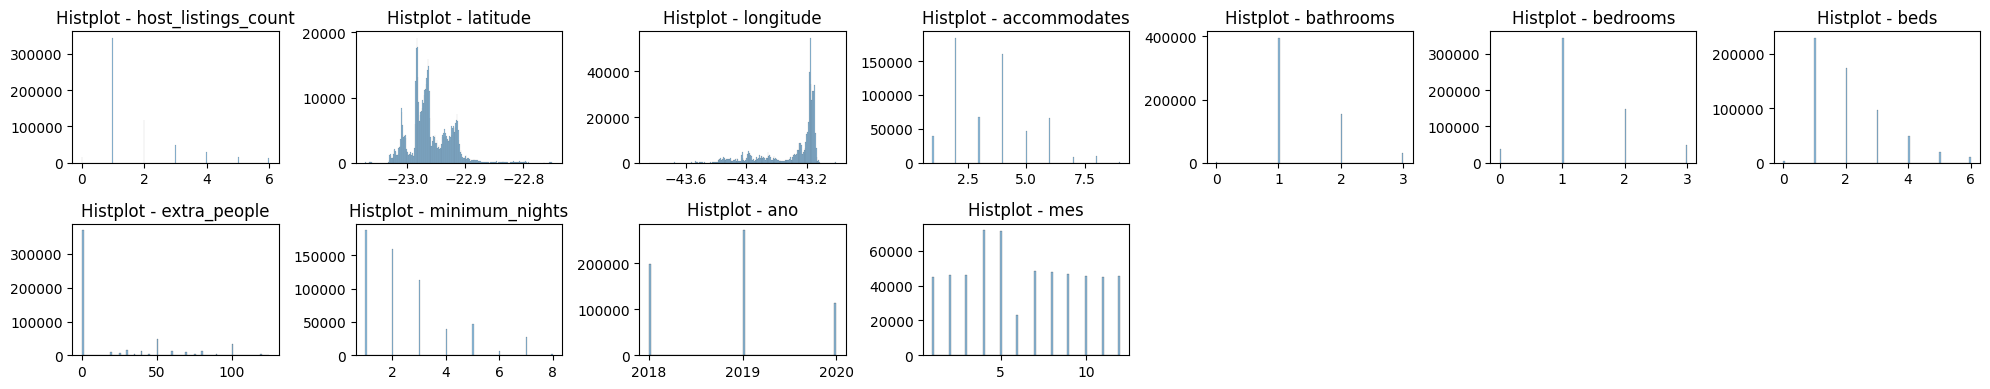

In [19]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb07_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.3.4. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [20]:
one_hot_encoder_columns = [
    'host_is_superhost',
    'property_type',
    'room_type',
    'bed_type',
    'instant_bookable',
    'is_business_travel_ready',
    'cancellation_policy',
    'host_listings_count',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
]

power_transformer_columns = [
   'extra_people',
   'latitude',
   'longitude',
]

min_max_scaler_columns = [
    'ano',
    'mes',
]

### 06.3.5. Criando uma função com o pipeline para treinar os modelos

In [21]:
def pipeline(X: pd.DataFrame, y: pd.Series, model: BaseEstimator) -> dict[str, Any]:
    """
    Função que executa todo o fluxo de machine learning: pré-processamento, seleção de features,
    balanceamento de classes, treinamento do modelo e validação cruzada.

    Args:
        X (pd.DataFrame): Valores de X.
        y (pd.Series): Variável alvo.
        model (BaseEstimator): Modelo de machine learning.

    Returns:
        dict: Dicionário com as métricas dos treinamentos.
    """

    pre_processing = ColumnTransformer([

        ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

        ('power_transformer', PowerTransformer(), power_transformer_columns),

        ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)

    ])

    pipeline = Pipeline([

        ('pre_processing', pre_processing),

        # Com k=20 deu um resultado igual sem aplicar essa etapa mas com tempo bem inferior
        # ('feature_selection', SelectKBest(score_func = f_regression, k = 10)), 

        ('model', model)

    ])

    scores = cross_validate(
        
        pipeline,

        X,

        y,

        cv = KFold(n_splits = 2, shuffle = True, random_state = consts.RANDOM_STATE),

        scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_squared_error'],

        n_jobs = -2

    )

    return scores

### 06.3.6. Treinando os modelos e armazenando suas métricas

In [22]:
scores = {

    'DummyRegressor': pipeline(X, y, DummyRegressor(strategy = 'mean')),

    'LinearRegression': pipeline(X, y, LinearRegression()),

    'DecisionTreeRegressor': pipeline(X, y, DecisionTreeRegressor(random_state = consts.RANDOM_STATE)),

    # 'ExtraTreesRegressor': pipeline(X, y, ExtraTreesRegressor(random_state = consts.RANDOM_STATE)),

    # 'RandomForestRegressor': pipeline(X, y, RandomForestRegressor(random_state = consts.RANDOM_STATE)),

    # 'AdaBoostRegressor': pipeline(X, y, AdaBoostRegressor(random_state = consts.RANDOM_STATE)),

    # 'XGBRegressor': pipeline(X, y, XGBRegressor(random_state = consts.RANDOM_STATE)),

}

### 06.3.7. Evitando overfitting dos modelos

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o K-Fold, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.

## 06.4. Seleção do modelo de classificação

### 06.4.1. Criando um dataset com as métricas dos treinamentos dos modelos

In [23]:
pd.set_option('display.max_rows', None)

for k, v in scores.items():

    scores[k]['time'] = scores[k]['fit_time'] + scores[k]['score_time']

df_metrics = pd.DataFrame(scores).T.reset_index().rename(columns = {'index': 'model'})

df_metrics = df_metrics.explode(df_metrics.columns[1:].to_list()).reset_index(drop = True)

df_metrics = df_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_metrics = df_metrics.drop(columns = ['fit_time', 'score_time'])

df_metrics

,model,r2,neg_root_mean_squared_error,neg_mean_absolute_error,neg_mean_squared_error,time
0,DummyRegressor,-0.000002,-262.220167,-198.84213,-68759.416,4.282898
1,DummyRegressor,-0.000002,-261.776746,-198.564383,-68527.064774,4.117467
2,LinearRegression,0.359024,-209.935802,-152.974153,-44073.040956,5.37269
3,LinearRegression,0.358727,-209.629462,-152.657412,-43944.511249,5.247325
4,DecisionTreeRegressor,0.920258,-74.047518,-18.962138,-5483.034916,164.227999
5,DecisionTreeRegressor,0.917602,-75.142959,-19.076264,-5646.464264,166.018533


### 06.4.2. Criando diagramas de caixa para comparar as métricas dos modelos

- Gráfico: Diagrama de Caixa.


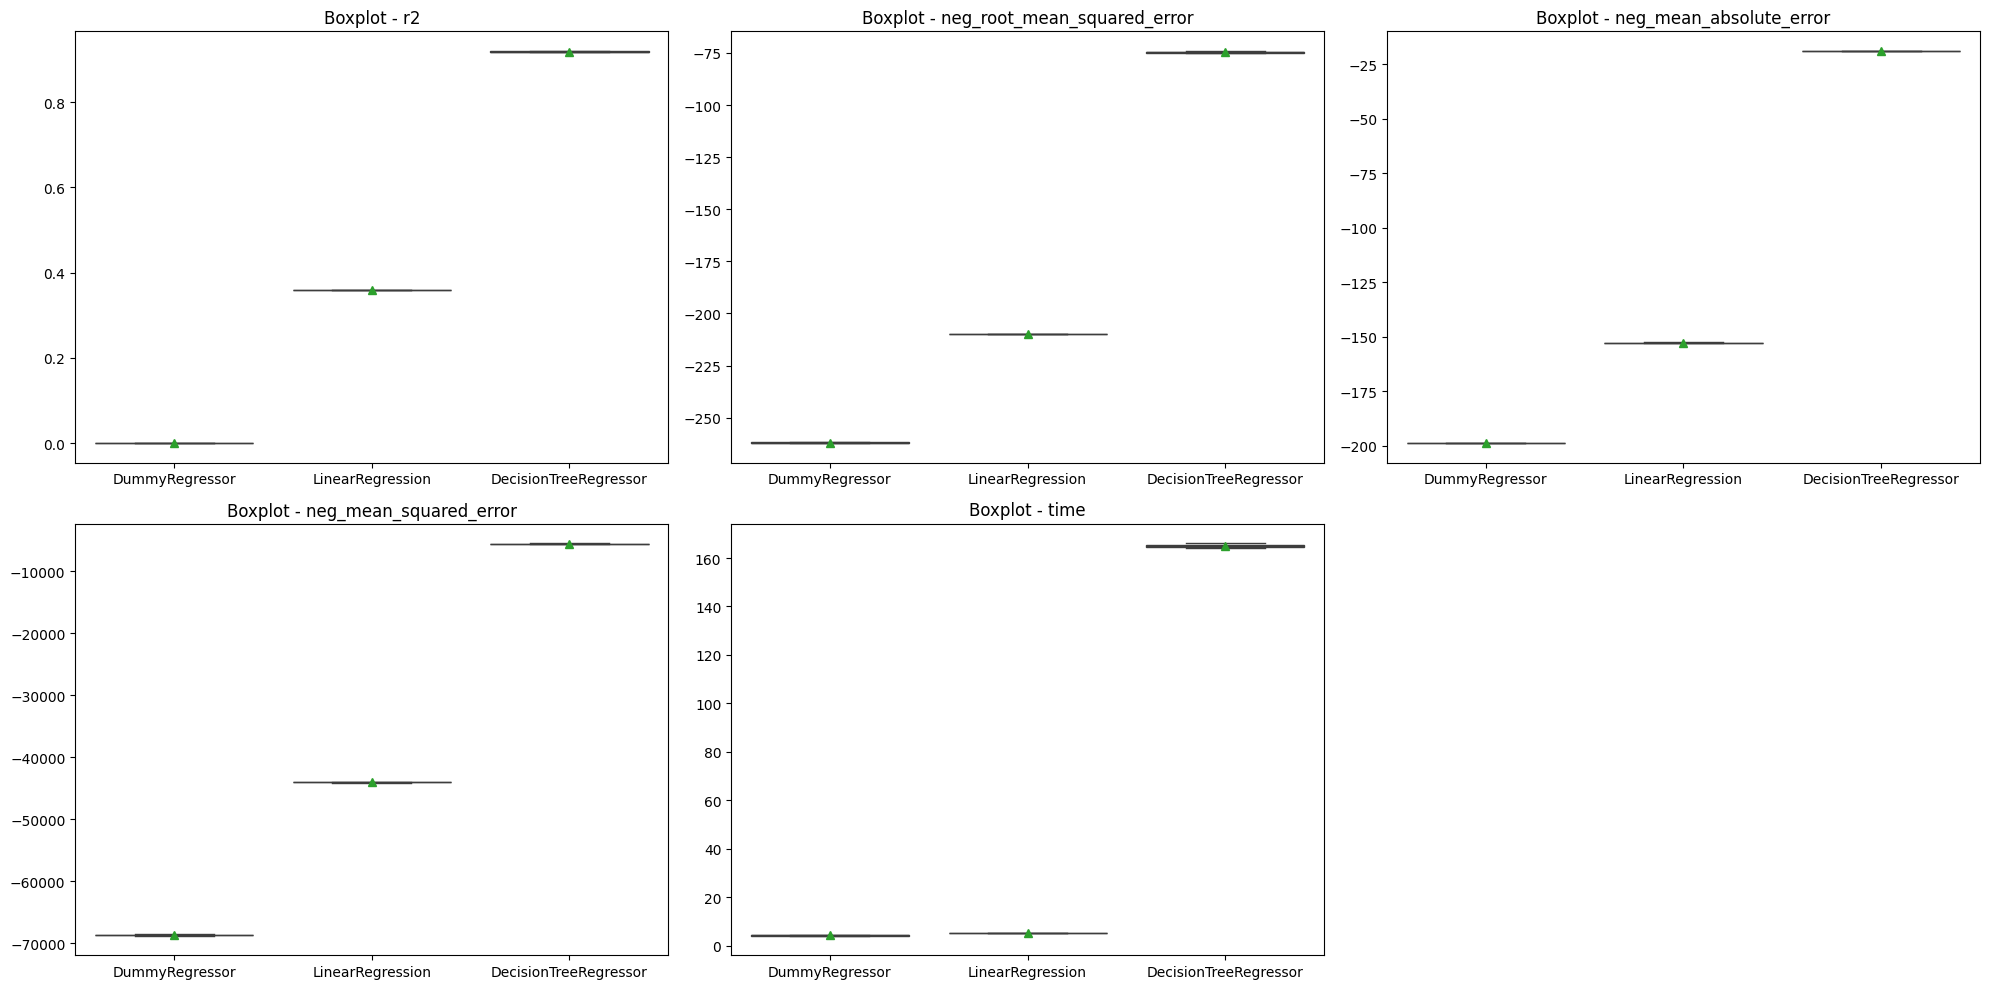

In [24]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_metrics, df_metrics.columns[1:].to_list(), 'model', 'model')

plt.savefig(f'../images/outputs/charts/pandas/nb07_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.4.3. Comparando a performance das métricas dos modelo

|Posição|R²                       |RMSE                     |MAE                      |MSE                      |Time                     |
|-------|-------------------------|-------------------------|-------------------------|-------------------------|-------------------------|
|Referência|Quanto maior melhor   |Quanto maior melhor      |Quanto maior melhor      | Quanto maior melhor     |Quanto menor melhor      |
|1      |**DecisionTreeRegressor**|**DecisionTreeRegressor**|**DecisionTreeRegressor**|**DecisionTreeRegressor**|DummyRegressor           |
|2      |LinearRegression         |LinearRegression         |LinearRegression         |LinearRegression         |LinearRegression         |
|3      |DummyRegressor           |DummyRegressor           |DummyRegressor           |DummyRegressor           |**DecisionTreeRegressor**|

### 06.4.4. Definindo o modelo selecionado

Após análise dos resultados de cada um dos modelos, é possível concluir que o modelo com os melhores resultados foi o de DecisionTreeRegressor, pois liderou os resultados nas métricas de R², RMSE, MAE e MSE, e apesar de ter sido o modelo que demorou mais para ser treinado não foi um tempo tão superior assim. Seria interessante testar outros modelos como ExtraTreesRegressor, RandomForestRegressor, AdaBoostRegressor e XGBRegressor que poderiam apresentar resultados melhores, porém como o dataset é bem grande optei por não utilizá-los para evitar custos e tempo de processamentos muito altos, mas com certeza são boas alternativas a serem testadas em cenários reais.

Portando, diante de todo esse contexto, **o melhor modelo para ser usado no projeto é o DecisionTreeRegressor**.

**Obs:** A tabela acima foi feita em cima de uma execução específica do notebook. A cada execução do notebook é possível que os valores das métricas variem um pouco, por isso pode ser que a tabela apresente uma ordem dos resultados levemente diferente de quando foi elaborada.